# 🎓 EduConnect ML Training Data Setup


**Phase 1.3: Stack Overflow Dataset Acquisition & Processing**

This notebook processes Stack Overflow data from Kaggle to create training data for our recommendation system.

## 1️⃣ Setup Kaggle API

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
import os

print("📤 Please upload your kaggle.json file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json



📤 Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json


## 2️⃣ Download Stack Overflow Dataset

In [ ]:
import os

os.makedirs('/data/raw', exist_ok=True)
os.makedirs('/data/processed', exist_ok=True)

print("✅ Directories created")
!kaggle datasets download -d stackoverflow/stacksample -p data/raw --unzip
print("\n✅ Dataset downloaded and extracted!")
!ls -lh data/raw/

✅ Directories created
Dataset URL: https://www.kaggle.com/datasets/stackoverflow/stacksample
License(s): other
 98% 1.09G/1.11G [00:10<00:00, 212MB/s]
100% 1.11G/1.11G [00:11<00:00, 108MB/s]

✅ Dataset downloaded and extracted!
total 3.4G
-rw-r--r-- 1 root root 1.5G Jan 29 14:48 Answers.csv
-rw-r--r-- 1 root root 1.8G Jan 29 14:48 Questions.csv
-rw-r--r-- 1 root root  63M Jan 29 14:48 Tags.csv


## 3️⃣ Preview Raw Data

In [ ]:
import pandas as pd
questions_df= pd.read_csv('data/raw/Answers.csv', nrows=10, encoding='ISO-8859-1')
print("📊 First 5 rows of Questions.csv:")
print("\nColumns:", list(questions_df.columns))
print("\n")
display(questions_df)

total_rows = sum(1 for _ in open('data/raw/Questions.csv', encoding='ISO-8859-1')) - 1
print(f"\n📈 Total questions in dataset: {total_rows:,}")

📊 First 5 rows of Questions.csv:

Columns: ['Id', 'OwnerUserId', 'CreationDate', 'ParentId', 'Score', 'Body']




,Id,OwnerUserId,CreationDate,ParentId,Score,Body
0,92,61,2008-08-01T14:45:37Z,90,13,"<p><a href=""http://svnbook.red-bean.com/"">Vers..."
1,124,26,2008-08-01T16:09:47Z,80,12,<p>I wound up using this. It is a kind of a ha...
2,199,50,2008-08-01T19:36:46Z,180,1,<p>I've read somewhere the human eye can't dis...
3,269,91,2008-08-01T23:49:57Z,260,4,"<p>Yes, I thought about that, but I soon figur..."
4,307,49,2008-08-02T01:49:46Z,260,28,"<p><a href=""http://www.codeproject.com/Article..."
5,332,59,2008-08-02T03:00:24Z,330,19,<p>I would be a bit reluctant to use nested cl...
6,344,100,2008-08-02T04:18:15Z,260,6,<p>You might be able to use IronRuby for that....
7,359,119,2008-08-02T06:16:23Z,260,5,"<P>You could use any of the DLR languages, whi..."
8,473,49,2008-08-02T15:33:13Z,470,8,"<p>No, what you're doing is fine. Don't let th..."
9,529,86,2008-08-02T18:16:07Z,180,3,<p>Isn't it also a factor which order you set ...



📈 Total questions in dataset: 42,420,635


## 4️⃣ Data Processing Functions

In [16]:
import re #removing white spaces and splitting tags
import html
from html.parser import HTMLParser

class MLStripper(HTMLParser):
  """Strip HTML tags from text"""
  def __init__(self):
    super().__init__()
    self.reset() #Ensures clean start for each text block
    self.strict=False #Allows malformed HTML and prevent parses crashes
    self.convert_charrefs=True  #Automatically converts: &lt; → < and Reduces noise in NLP text
    self.text=[]; #A list that will store text chunks


  def handle_data(self, d):
    self.text.append(d)

  def get_data(self):
    return ''.join(self.text) #Joins all text pieces into one clean string and now no HTML tags remain


def strip_html(html_text):
  """Remove HTML tags from text"""
  if pd.isna(html_text):  #Checks for: NAN and None
    return ''
  s=MLStripper()
  s.feed(str(html_text))  #Ensures input is always a string
  text=s.get_data()

  text=html.unescape(text)  #decode html entities like "Tom &amp; Jerry" → "Tom & Jerry"
  return text

def clean_text(text, max_length=2000):
  """Clean and normalize text"""
  if(pd.isna(text)):
    return ''

  text=strip_html(text)
  text = re.sub(r'http\S+|www\S+', '', text)  #remove the starting http and www from the URLS and replace them the spaces''
  text = re.sub(r'\s+', ' ', text) #replaces white spaces, next lines, tab spaces with single space
  text = text.strip()[:max_length] #remove leading/trailing spaces and add a maxlength cap so that training is fast
  return text


def extract_tags(tags_str):
  """Extract tags from various formats"""
  if(pd.isna(tags_str)):
    return []

  tags_str=str(tags_str)

  if '<' in tags_str and '>' in tags_str:
    tags=re.findall(r'<([^>]+)>', tags_str)  #convert "<python><react>" → ["python", "react"]
  elif ',' in tags_str or ';' in tags_str:
    tags=re.split(r'[,;]', tags_str)  #Splits on commas or semicolons.
  else:
    tags=tags_str.split()


  tags=[tag.strip().lower() for tag in tags if tag.strip()]
  tags=[tag for tag in tags if len(tag)>1 and len(tag)<50]

  return tags

print("Processing functions defined")
#TEST FOR FUNCTIONS
test_html = "<p>This is a <strong>test</strong> with <a href='url'>link</a></p>"
test_tags = "<python><javascript><react>"

print("\n🧪 Testing functions:")
print(f"HTML: {test_html}")
print(f"Cleaned: {clean_text(test_html)}")
print(f"\nTags: {test_tags}")
print(f"Extracted: {extract_tags(test_tags)}")

Processing functions defined

🧪 Testing functions:
HTML: <p>This is a <strong>test</strong> with <a href='url'>link</a></p>
Cleaned: This is a test with link

Tags: <python><javascript><react>
Extracted: ['python', 'javascript', 'react']


## 5️⃣ Process Dataset

**Configuration:**
- Minimum score: 5 (quality posts)
- Minimum views: 100 (popular posts)
- Maximum posts: 10,000 (adjust for testing/production)

Adjust these values below:

In [17]:
import pandas as pd
import json
from datetime import datetime
from collections import Counter
from tqdm import tqdm

CONFIG = {
    'min_score': 5,
    'max_posts': 10000,
    'min_answer_count': 1,
    'batch_size': 1000,
}


for key, value in CONFIG.items():
  print(f"    {key}: {value}")
print("\n🔄 Processing dataset...")


def normalize_tag(tag):
    """Clean a single tag value; return None if invalid."""
    if pd.isna(tag):
        return None
    tag = str(tag).strip().lower()
    if not tag:
        return None
    if len(tag) <= 1 or len(tag) >= 50:
        return None
    return tag


tags_df = pd.read_csv('data/raw/Tags.csv', encoding='ISO-8859-1', usecols=['Id', 'Tag'])
tags_df['Tag'] = tags_df['Tag'].map(normalize_tag)
tags_df = tags_df[tags_df['Tag'].notna()]        # drop invalid/NaN tags
tags_grouped = tags_df.groupby('Id')['Tag'].apply(list).to_dict()

answers_df = pd.read_csv(
    'data/raw/Answers.csv',
    encoding='ISO-8859-1',
    usecols=['ParentId']
)
answer_count_map = answers_df['ParentId'].value_counts().to_dict()

chunk_size = 5000
processed_posts = []
all_tags = []
processed_count = 0

#PROGRESS BAR
reader = pd.read_csv(
    'data/raw/Questions.csv',
    chunksize=chunk_size,
    encoding='ISO-8859-1',
    low_memory=False,
    usecols=['Id', 'CreationDate', 'Score', 'Title', 'Body']
)


for chunk_num, chunk in enumerate(tqdm(reader, desc="Processing chunks")):
  filtered=chunk[
      (chunk['Score']>=CONFIG['min_score']) &
      (chunk['Title'].notna()) &
      (chunk['Body'].notna())
  ]

  for _, row in filtered.iterrows():
    if processed_count>=CONFIG['max_posts']:
      break

    qid = row['Id']

    tags = tags_grouped.get(qid, [])
    if not tags:
        continue

    answer_count=answer_count_map.get(qid, 0)
    if answer_count<CONFIG['min_answer_count']:
      continue

    post_data={
        'post_id': qid,
        'title': clean_text(row['Title'], max_length=200),
        'body': clean_text(row['Body'], max_length=2000),
        'tags': ','.join(tags),
        'score': int(row['Score']),
        'answer_count': int(answer_count),
        'creation_date': row['CreationDate'],
    }

    processed_posts.append(post_data)
    all_tags.extend(tags)
    processed_count+=1

  if processed_count>=CONFIG['max_posts']:
    print(f"\n✅ Reached maximum of {CONFIG['max_posts']} posts")
    break

#Save
print(f"\n✅ Processing complete!")
print(f"📊 Total posts processed: {len(processed_posts):,}")


    min_score: 5
    max_posts: 10000
    min_answer_count: 1
    batch_size: 1000

🔄 Processing dataset...


Processing chunks: 6it [00:03,  1.99it/s]


✅ Reached maximum of 10000 posts

✅ Processing complete!
📊 Total posts processed: 10,000


## 6️⃣ Generate Statistics

In [19]:
import os

os.makedirs('data/processed', exist_ok=True)


📊 DATASET STATISTICS

Total Posts: 10,000
Unique Tags: 4,428

📈 Score Statistics:
   Mean: 33.09
   Median: 11.00
   Range: 5 - 5190

 Answer Count Statistics:
   Mean: 5.95
   Median: 5.00
   Range: 1 - 408

🏷️  Top 10 Tags:
   1. c#: 1,371
   2. java: 901
   3. .net: 843
   4. c++: 622
   5. python: 570
   6. javascript: 509
   7. php: 390
   8. asp.net: 380
   9. jquery: 303
   10. sql: 300


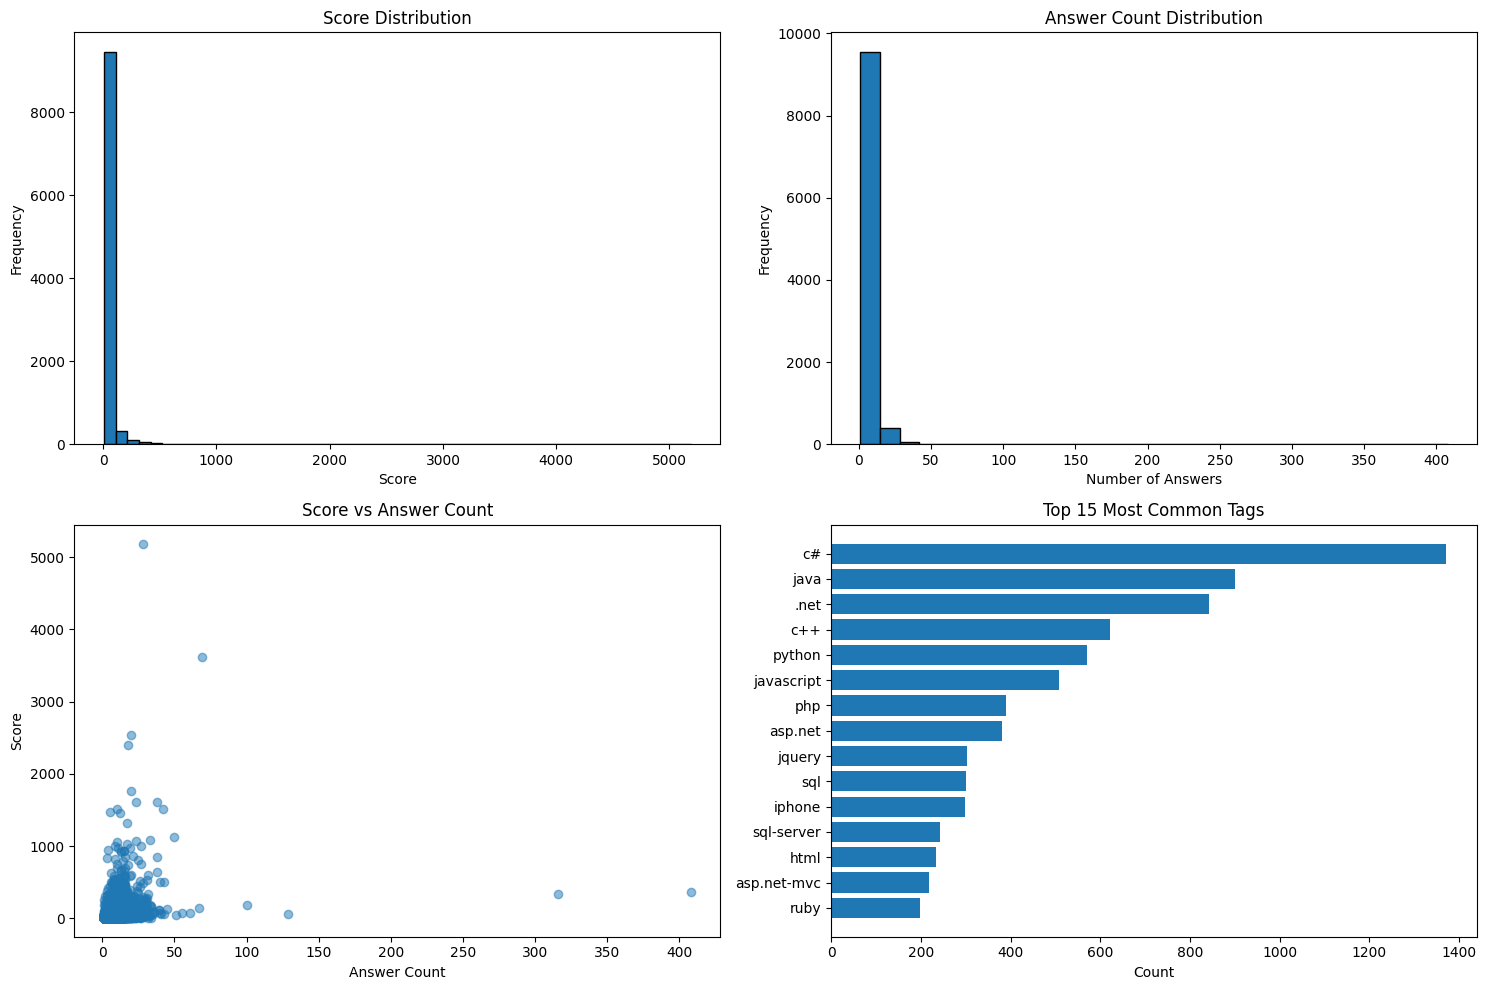


✅ Statistics saved to: data/processed/dataset-statistics.json
✅ Visualizations saved to: data/processed/dataset-visualizations.png


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate statistics
df = pd.DataFrame(processed_posts)

tag_counts = Counter(all_tags)
top_tags = tag_counts.most_common(30)

stats = {
    'total_posts': len(processed_posts),
    'unique_tags': len(tag_counts),
    'score_stats': {
        'mean': float(df['score'].mean()),
        'median': float(df['score'].median()),
        'min': int(df['score'].min()),
        'max': int(df['score'].max())
    },
    'answer_count_stats': {
        'mean': float(df['answer_count'].mean()),
        'median': float(df['answer_count'].median()),
        'min': int(df['answer_count'].min()),
        'max': int(df['answer_count'].max())
    },
    'top_30_tags': [
        {'tag': tag, 'count': count}
        for tag, count in top_tags
    ],
    'processed_at': datetime.now().isoformat()
}

# Save statistics
with open('data/processed/dataset-statistics.json', 'w') as f:
    json.dump(stats, f, indent=2)

# Print statistics
print("📊 DATASET STATISTICS")
print("=" * 50)
print(f"\nTotal Posts: {stats['total_posts']:,}")
print(f"Unique Tags: {stats['unique_tags']:,}")

print("\n📈 Score Statistics:")
print(f"   Mean: {stats['score_stats']['mean']:.2f}")
print(f"   Median: {stats['score_stats']['median']:.2f}")
print(f"   Range: {stats['score_stats']['min']} - {stats['score_stats']['max']}")

print("\n Answer Count Statistics:")
print(f"   Mean: {stats['answer_count_stats']['mean']:.2f}")
print(f"   Median: {stats['answer_count_stats']['median']:.2f}")
print(f"   Range: {stats['answer_count_stats']['min']} - {stats['answer_count_stats']['max']}")

print("\n🏷️  Top 10 Tags:")
for i, item in enumerate(stats['top_30_tags'][:10], 1):
    print(f"   {i}. {item['tag']}: {item['count']:,}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Score distribution
axes[0, 0].hist(df['score'], bins=50, edgecolor='black')
axes[0, 0].set_title('Score Distribution')
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_ylabel('Frequency')

# Answer count distribution
axes[0, 1].hist(df['answer_count'], bins=30, edgecolor='black')
axes[0, 1].set_title('Answer Count Distribution')
axes[0, 1].set_xlabel('Number of Answers')
axes[0, 1].set_ylabel('Frequency')

# Scatter: score vs answer_count (how score relates to answers)
axes[1, 0].scatter(df['answer_count'], df['score'], alpha=0.5)
axes[1, 0].set_title('Score vs Answer Count')
axes[1, 0].set_xlabel('Answer Count')
axes[1, 0].set_ylabel('Score')

# Top 15 tags
top_15_tags = [item['tag'] for item in stats['top_30_tags'][:15]]
top_15_counts = [item['count'] for item in stats['top_30_tags'][:15]]
axes[1, 1].barh(top_15_tags[::-1], top_15_counts[::-1])
axes[1, 1].set_title('Top 15 Most Common Tags')
axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('data/processed/dataset-visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Statistics saved to: data/processed/dataset-statistics.json")
print("✅ Visualizations saved to: data/processed/dataset-visualizations.png")

## 7️⃣ Export Training Data

In [21]:
# Save to CSV
output_file = 'data/processed/training-data.csv'
df.to_csv(output_file, index=False)

print(f"✅ Training data exported to: {output_file}")
print(f"📊 Total rows: {len(df):,}")
print(f"💾 File size: {os.path.getsize(output_file) / 1024 / 1024:.2f} MB")

# Preview the data
print("\n📋 Preview of training data:")
display(df.head(10))

print("\n📂 Columns:")
for col in df.columns:
    print(f"   - {col}")

✅ Training data exported to: data/processed/training-data.csv
📊 Total rows: 10,000
💾 File size: 7.06 MB

📋 Preview of training data:


,post_id,title,body,tags,score,answer_count,creation_date
0,80,SQLStatement.execute() - multiple queries in o...,I've written a database generation script in S...,"flex,actionscript-3,air",26,3,2008-08-01T13:57:07Z
1,90,Good branching and merging tutorials for Torto...,Are there any really good tutorials explaining...,"svn,tortoisesvn,branch,branching-and-merging",144,3,2008-08-01T14:41:24Z
2,120,ASP.NET Site Maps,Has anyone got experience creating SQL-based A...,"sql,asp.net,sitemap",21,1,2008-08-01T15:50:08Z
3,180,Function for creating color wheels,This is something I've pseudo-solved many time...,"algorithm,language-agnostic,colors,color-space",53,9,2008-08-01T18:42:19Z
4,260,Adding scripting functionality to .NET applica...,I have a little game written in C#. It uses a ...,"c#,.net,scripting,compiler-construction",49,9,2008-08-01T23:22:08Z
5,330,Should I use nested classes in this case?,I am working on a collection of classes used f...,"c++,oop,class,nested-class",29,10,2008-08-02T02:51:36Z
6,470,Homegrown consumption of web services,I've been writing a few web services for a .ne...,".net,web-services",13,1,2008-08-02T15:11:47Z
7,580,Deploying SQL Server Databases from Test to Live,I wonder how you guys manage deployment of a d...,"sql-server,sql-server-2005,deployment,release-...",21,14,2008-08-02T23:30:59Z
8,650,Automatically update version number,I would like the version property of my applic...,"c#,visual-studio,versioning",79,6,2008-08-03T11:12:52Z
9,810,Visual Studio Setup Project - Per User Registr...,I'm trying to maintain a Setup Project in Visu...,"windows,visual-studio,registry,installation",9,4,2008-08-03T20:35:01Z



📂 Columns:
   - post_id
   - title
   - body
   - tags
   - score
   - answer_count
   - creation_date


## 8️⃣ Download Files

Download these files to use in your VS Code project:

In [23]:
from google.colab import files
import shutil

# Create a zip file with all processed data
print("📦 Creating zip file...")
shutil.make_archive('educonnect-training-data', 'zip', 'data/processed')

print("\n📥 Downloading files...")
print("   This may take a few moments depending on file size\n")

# Download the zip file
files.download('educonnect-training-data.zip')

print("\n✅ Download complete!")
print("\n📌 Next Steps:")
print("   1. Extract the zip file in your VS Code project")
print("   2. Place files in: ml-training/data/processed/")
print("   3. Proceed to Phase 2: Embedding Generation")

📦 Creating zip file...

📥 Downloading files...
   This may take a few moments depending on file size



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download complete!

📌 Next Steps:
   1. Extract the zip file in your VS Code project
   2. Place files in: ml-training/data/processed/
   3. Proceed to Phase 2: Embedding Generation


## 🎯 Summary

**What we accomplished:**
1. ✅ Downloaded Stack Overflow dataset from Kaggle
2. ✅ Filtered high-quality posts (score ≥ 5, views ≥ 100)
3. ✅ Cleaned and normalized text data
4. ✅ Extracted and processed tags
5. ✅ Generated statistics and visualizations
6. ✅ Exported training data as CSV

**Files generated:**
- `training-data.csv` - Main training dataset
- `dataset-statistics.json` - Dataset statistics
- `dataset-visualizations.png` - Data visualizations
